In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'TOC.xlsx'  # Change this to your actual file path
sheet1_data = pd.read_excel(file_path, sheet_name='Sheet1')

# Clean column names
sheet1_data.columns = sheet1_data.columns.str.strip()


# Clean column names by stripping any leading/trailing whitespace
sheet1_data.columns = sheet1_data.columns.str.strip()

# Function to convert 'min:sec' format to timedelta (in seconds)
def convert_to_timedelta(time_str):
    try:
        minutes, seconds = time_str.split(':')
        return pd.to_timedelta(f'{minutes}m{seconds}s').total_seconds()
    except:
        return None  # Handle any possible malformed entries

# Apply the conversion to both 'VR TOTAL TIME' and 'AT TOTAL TIME'
sheet1_data['VR TOTAL TIME'] = sheet1_data['VR TOTAL TIME'].apply(convert_to_timedelta)
sheet1_data['AT TOTAL TIME'] = sheet1_data['AT TOTAL TIME'].apply(convert_to_timedelta)



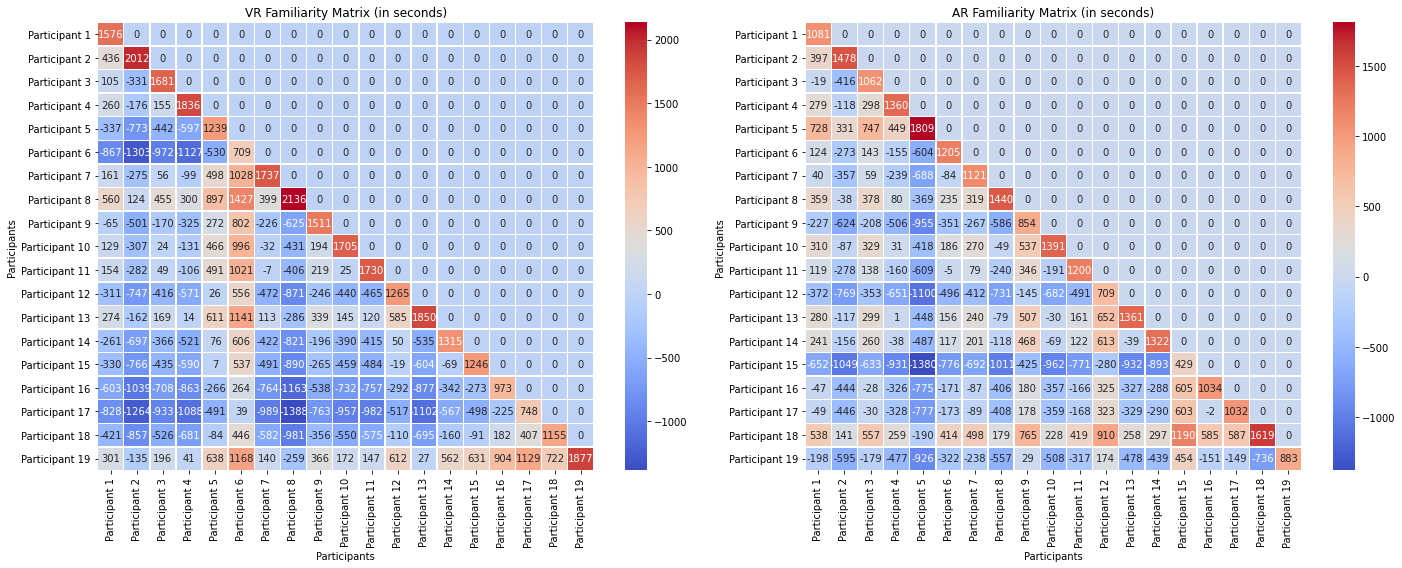

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have already cleaned the data and converted the time columns to seconds

# Function to create familiarity matrix for a given time column (VR or AR)
def create_familiarity_matrix_in_seconds(time_column, title):
    participant_scores = sheet1_data[time_column]  # Already in seconds
    num_participants = len(participant_scores)
    
    # Initialize the familiarity matrix (differences between participants in seconds)
    familiarity_matrix = np.zeros((num_participants, num_participants))
    
    # Fill in the diagonal with participant's own time and off-diagonal with differences
    for i in range(num_participants):
        for j in range(i + 1):
            if i == j:
                familiarity_matrix[i, j] = participant_scores.iloc[i]  # Diagonal: participant's own score (in seconds)
            else:
                # Difference between participants (in seconds)
                familiarity_matrix[i, j] = participant_scores.iloc[i] - participant_scores.iloc[j]
    
    # Convert the familiarity matrix into a DataFrame for better visualization
    familiarity_matrix_df = pd.DataFrame(familiarity_matrix, 
                                         columns=[f'Participant {i+1}' for i in range(num_participants)],
                                         index=[f'Participant {i+1}' for i in range(num_participants)])
    
    return familiarity_matrix_df

# Create familiarity matrices for both VR and AR times in seconds
vr_familiarity_matrix_seconds = create_familiarity_matrix_in_seconds('VR TOTAL TIME', 'VR TOTAL TIME')
ar_familiarity_matrix_seconds = create_familiarity_matrix_in_seconds('AT TOTAL TIME', 'AR TOTAL TIME')

# Plot side-by-side heatmaps for VR and AR times (in seconds)
def plot_side_by_side_heatmaps(vr_matrix, ar_matrix, title1, title2):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # VR heatmap
    sns.heatmap(vr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, ax=ax1, cbar=True, fmt='.0f')
    ax1.set_title(title1)
    ax1.set_xlabel('Participants')
    ax1.set_ylabel('Participants')

    # AR heatmap
    sns.heatmap(ar_matrix, annot=True, cmap='coolwarm', linewidths=0.5, ax=ax2, cbar=True, fmt='.0f')
    ax2.set_title(title2)
    ax2.set_xlabel('Participants')
    ax2.set_ylabel('Participants')

    plt.tight_layout()
    plt.show()

# Call the function to plot VR and AR heatmaps side by side (in seconds)
plot_side_by_side_heatmaps(vr_familiarity_matrix_seconds, ar_familiarity_matrix_seconds, 
                           'VR Familiarity Matrix (in seconds)', 'AR Familiarity Matrix (in seconds)')


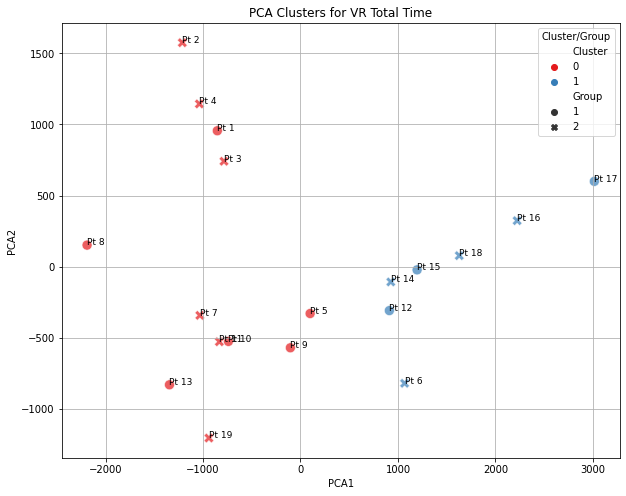

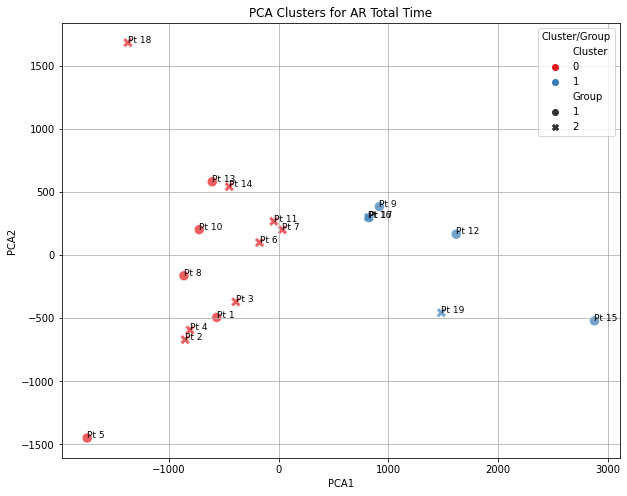


VR Cluster Assignments:     Participant  Cluster  Group
0             1        0      1
1             2        0      2
2             3        0      2
3             4        0      2
4             5        0      1
5             6        1      2
6             7        0      2
7             8        0      1
8             9        0      1
9            10        0      1
10           11        0      2
11           12        1      1
12           13        0      1
13           14        1      2
14           15        1      1
15           16        1      2
16           17        1      1
17           18        1      2
18           19        0      2     Cluster
0         0
1         0
2         0
3         0
4         0
5         0
6         0
7         0
8         1
9         0
10        0
11        1
12        0
13        0
14        1
15        1
16        1
17        0
18        1


In [10]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure Participant IDs are integers for merging
sheet1_data['Participant_ID'] = sheet1_data.index + 1

# Function to apply K-Means clustering on the familiarity matrix
def cluster_participants(familiarity_matrix, n_clusters=2):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(familiarity_matrix)
    
    # Create a DataFrame to hold participant cluster assignments
    cluster_data = pd.DataFrame({
        'Participant': np.arange(1, familiarity_matrix.shape[0] + 1),
        'Cluster': cluster_labels
    })
    
    return cluster_data, kmeans

# Cluster participants based on VR and AR familiarity matrices
vr_cluster_data, vr_kmeans = cluster_participants(vr_familiarity_matrix_seconds)
ar_cluster_data, ar_kmeans = cluster_participants(ar_familiarity_matrix_seconds)

# Merge cluster data with the original sheet1_data to include original group info
vr_cluster_data = pd.merge(vr_cluster_data, sheet1_data[['Participant_ID', 'Group']], 
                           left_on='Participant', right_on='Participant_ID')
ar_cluster_data = pd.merge(ar_cluster_data, sheet1_data[['Participant_ID', 'Group']], 
                           left_on='Participant', right_on='Participant_ID')

# PCA plot function
def plot_pca_clusters(familiarity_matrix_df, cluster_data, title):
    # Perform PCA to reduce familiarity matrix to 2D
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(familiarity_matrix_df)
    
    # Create DataFrame for PCA results
    pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
    pca_df['Cluster'] = cluster_data['Cluster']
    pca_df['Group'] = cluster_data['Group']
    pca_df['Participant'] = cluster_data['Participant']
    
    # Plot PCA results with clusters and groups
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', style='Group', 
                    data=pca_df, palette='Set1', s=100, alpha=0.7)
    
    for i in range(len(pca_df)):
        plt.text(pca_df['PCA1'][i] + 0.02, pca_df['PCA2'][i], f"Pt {pca_df['Participant'][i]}", fontsize=9)
    
    plt.title(f'PCA Clusters for {title}')
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.grid(True)
    plt.legend(title='Cluster/Group')
    plt.show()

# Plot PCA clusters for VR and AR times
plot_pca_clusters(vr_familiarity_matrix_seconds, vr_cluster_data, 'VR Total Time')
plot_pca_clusters(ar_familiarity_matrix_seconds, ar_cluster_data, 'AR Total Time')



In [11]:
# Function to calculate mean and standard deviation for each cluster
def calculate_cluster_stats(cluster_data, time_column):
    # Merge the cluster data with the original sheet1_data to access time columns
    merged_data = pd.merge(cluster_data, sheet1_data[['Participant_ID', time_column]], 
                           left_on='Participant', right_on='Participant_ID')
    
    # Calculate statistics per cluster
    cluster_stats = merged_data.groupby('Cluster').agg({
        time_column: ['mean', 'std']
    }).reset_index()

    # Rename columns for clarity
    cluster_stats.columns = ['Cluster', 'Mean Time (s)', 'Std Dev Time (s)']
    
    return cluster_stats

# Calculate cluster stats for VR and AR times
vr_cluster_stats = calculate_cluster_stats(vr_cluster_data, 'VR TOTAL TIME')
ar_cluster_stats = calculate_cluster_stats(ar_cluster_data, 'AT TOTAL TIME')

# Print the statistics for VR and AR clusters
print("\nVR Cluster Stats (Mean and Std Dev in seconds):\n", vr_cluster_stats)
print("\nAR Cluster Stats (Mean and Std Dev in seconds):\n", ar_cluster_stats)

merged_clusters = pd.merge(vr_cluster_data[['Participant', 'Cluster', 'Group']], 
                           ar_cluster_data[['Participant', 'Cluster']], 
                           on='Participant', suffixes=('_VR', '_AR'))

# Print the merged cluster assignments
print("\nMerged Cluster Assignments (Participant, VR Cluster, Group, AR Cluster):\n", merged_clusters)




VR Cluster Stats (Mean and Std Dev in seconds):
    Cluster  Mean Time (s)  Std Dev Time (s)
0        0    1740.833333        234.720272
1        1    1058.714286        251.254661

AR Cluster Stats (Mean and Std Dev in seconds):
    Cluster  Mean Time (s)  Std Dev Time (s)
0        0    1342.230769        216.159337
1        1     823.500000        228.470348

Merged Cluster Assignments (Participant, VR Cluster, Group, AR Cluster):
     Participant  Cluster_VR  Group  Cluster_AR
0             1           0      1           0
1             2           0      2           0
2             3           0      2           0
3             4           0      2           0
4             5           0      1           0
5             6           1      2           0
6             7           0      2           0
7             8           0      1           0
8             9           0      1           1
9            10           0      1           0
10           11           0      2          

In [12]:
# Define the function to filter participants based on their cluster combinations
def print_participants_by_cluster_combination(merged_clusters):
    # Filter participants by cluster combinations and groups (00, 01, 10, 11)
    
    # 00: VR Cluster = 0, AR Cluster = 0
    cluster_00 = merged_clusters[(merged_clusters['Cluster_VR'] == 0) & (merged_clusters['Cluster_AR'] == 0)]
    
    # 01: VR Cluster = 0, AR Cluster = 1
    cluster_01 = merged_clusters[(merged_clusters['Cluster_VR'] == 0) & (merged_clusters['Cluster_AR'] == 1)]
    
    # 10: VR Cluster = 1, AR Cluster = 0
    cluster_10 = merged_clusters[(merged_clusters['Cluster_VR'] == 1) & (merged_clusters['Cluster_AR'] == 0)]
    
    # 11: VR Cluster = 1, AR Cluster = 1
    cluster_11 = merged_clusters[(merged_clusters['Cluster_VR'] == 1) & (merged_clusters['Cluster_AR'] == 1)]
    
    # Print participants in each combination, grouped by their original group
    print("\nParticipants in Cluster (00) - VR: 0, AR: 0\n", cluster_00)
    print("\nParticipants in Cluster (01) - VR: 0, AR: 1\n", cluster_01)
    print("\nParticipants in Cluster (10) - VR: 1, AR: 0\n", cluster_10)
    print("\nParticipants in Cluster (11) - VR: 1, AR: 1\n", cluster_11)

# Call the function to print participants based on cluster combinations
print_participants_by_cluster_combination(merged_clusters)



Participants in Cluster (00) - VR: 0, AR: 0
     Participant  Cluster_VR  Group  Cluster_AR
0             1           0      1           0
1             2           0      2           0
2             3           0      2           0
3             4           0      2           0
4             5           0      1           0
6             7           0      2           0
7             8           0      1           0
9            10           0      1           0
10           11           0      2           0
12           13           0      1           0

Participants in Cluster (01) - VR: 0, AR: 1
     Participant  Cluster_VR  Group  Cluster_AR
8             9           0      1           1
18           19           0      2           1

Participants in Cluster (10) - VR: 1, AR: 0
     Participant  Cluster_VR  Group  Cluster_AR
5             6           1      2           0
13           14           1      2           0
17           18           1      2           0

Participants in

In [ ]:


# Function to perform clustering
def cluster_participants(data, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(data)
    return clusters

# Function to perform PCA and plot clusters
def plot_pca_clusters(familiarity_matrix_df, clusters, title):
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(familiarity_matrix_df)
    pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
    pca_df['Cluster'] = clusters

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='Set1', s=100, alpha=0.7)
    plt.title(title)
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.grid(True)
    plt.show()

# Function to visualize clusters using a heatmap
def visualize_clusters(familiarity_matrix_df, clusters, title):
    sorted_indices = np.argsort(clusters)
    sorted_familiarity_matrix = familiarity_matrix_df.iloc[sorted_indices, sorted_indices]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(sorted_familiarity_matrix, annot=True, cmap='coolwarm', linewidths=0.5, cbar=True)
    plt.title(f'Clustered Familiarity Matrix for {title}')
    plt.show()

# Simplified main function
def main(data):
    # Assume data has been preprocessed and contains relevant features
    familiarity_matrix = data.corr()  # Example similarity matrix
    clusters = cluster_participants(familiarity_matrix, n_clusters=3)

    # Plot clusters in PCA space
    plot_pca_clusters(familiarity_matrix, clusters, "PCA Clusters")

    # Visualize clusters in heatmap
    visualize_clusters(familiarity_matrix, clusters, "Familiarity Matrix")

# Example usage
# data = pd.read_csv("your_data.csv")  # Load your data here
# main(data)  # Run the clustering and visualization


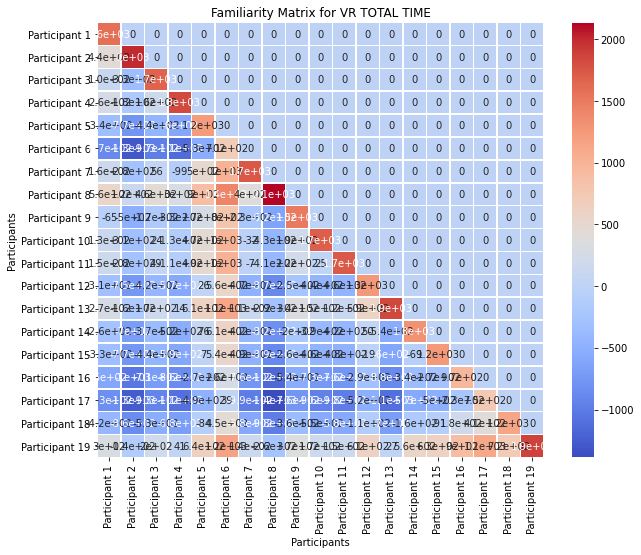


Cluster Statistics for VR TOTAL TIME:
    Cluster  Participant                                 Group
0        0            7                 [2, 1, 2, 1, 2, 1, 2]
1        1           12  [1, 2, 2, 2, 1, 2, 1, 1, 1, 2, 1, 2]


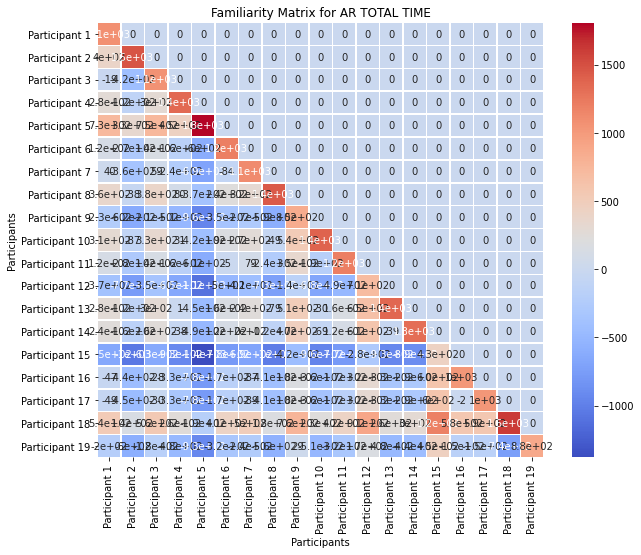


Cluster Statistics for AR TOTAL TIME:
    Cluster  Participant                                    Group
0        0           13  [1, 2, 2, 2, 1, 2, 2, 1, 1, 2, 1, 2, 2]
1        1            6                       [1, 1, 1, 2, 1, 2]


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Load your dataset (replace with your own dataset path if needed)
file_path = 'TOC.xlsx'  # Change this to your actual file path
sheet1_data = pd.read_excel(file_path, sheet_name='Sheet1')

# Clean column names
sheet1_data.columns = sheet1_data.columns.str.strip()

# Convert 'VR TOTAL TIME' and 'AT TOTAL TIME' to timedelta format
def convert_to_timedelta(time_str):
    minutes, seconds = time_str.split(':')
    return pd.to_timedelta(f'{minutes}m{seconds}s')

sheet1_data['VR TOTAL TIME'] = sheet1_data['VR TOTAL TIME'].apply(convert_to_timedelta)
sheet1_data['AT TOTAL TIME'] = sheet1_data['AT TOTAL TIME'].apply(convert_to_timedelta)

# Function to create familiarity matrix and perform clustering
def create_familiarity_matrix_and_cluster(time_column, title):
    # Convert participant times to total seconds for calculation
    participant_scores = sheet1_data[time_column].dt.total_seconds()
    num_participants = len(participant_scores)
    
    # Initialize the familiarity matrix (differences between participants)
    familiarity_matrix = np.zeros((num_participants, num_participants))
    
    # Fill in the diagonal and below diagonal with differences (non-absolute)
    for i in range(num_participants):
        for j in range(i + 1):
            if i == j:
                familiarity_matrix[i, j] = participant_scores[i]  # Diagonal: participant's own score
            else:
                familiarity_matrix[i, j] = participant_scores[i] - participant_scores[j]  # Difference between participants
    
    # Convert the familiarity matrix into a DataFrame for better visualization
    familiarity_matrix_df = pd.DataFrame(familiarity_matrix, 
                                         columns=[f'Participant {i+1}' for i in range(num_participants)],
                                         index=[f'Participant {i+1}' for i in range(num_participants)])
    
    # Create a heatmap for the familiarity matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(familiarity_matrix_df, annot=True, cmap='coolwarm', linewidths=0.5, cbar=True)
    plt.title(f'Familiarity Matrix for {title}')
    plt.xlabel('Participants')
    plt.ylabel('Participants')
    plt.show()

    # Apply clustering (e.g., K-Means) on the familiarity matrix
    kmeans = KMeans(n_clusters=2)
    labels = kmeans.fit_predict(familiarity_matrix)
    
    # Attach clustering results to participants
    cluster_data = pd.DataFrame({
        'Participant': [f'Participant {i+1}' for i in range(num_participants)],
        'Cluster': labels,
        'Group': sheet1_data['Group']
    })
    
    # Calculate mean and standard deviation for each cluster
    cluster_stats = cluster_data.groupby('Cluster').agg({
        'Participant': 'count',  # Number of participants in the cluster
        'Group': lambda x: list(x)  # List the groups in the cluster
    }).reset_index()
    
    print(f'\nCluster Statistics for {title}:\n', cluster_stats)
    
    # Return the familiarity matrix and clustering results
    return familiarity_matrix_df, cluster_data

# Create familiarity matrices and clusters for both VR and AR times
vr_familiarity_matrix, vr_cluster_data = create_familiarity_matrix_and_cluster('VR TOTAL TIME', 'VR TOTAL TIME')
ar_familiarity_matrix, ar_cluster_data = create_familiarity_matrix_and_cluster('AT TOTAL TIME', 'AR TOTAL TIME')


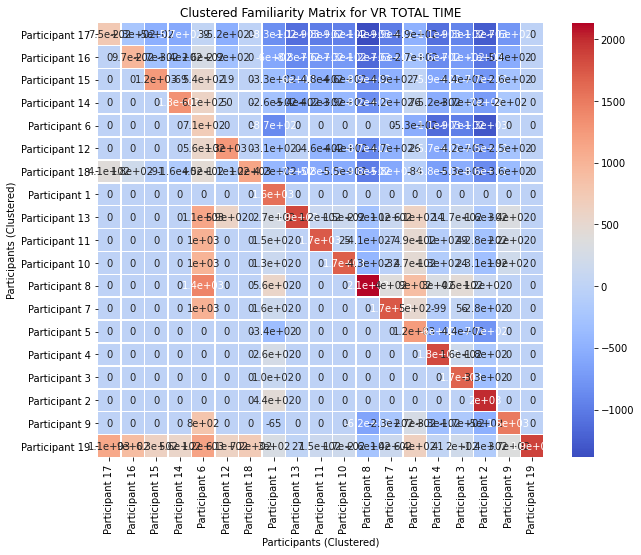

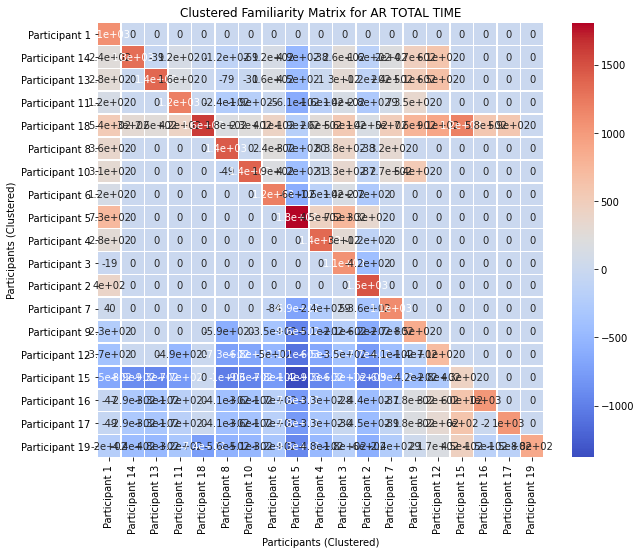

In [8]:
# Visualize the clusters using the heatmap for the familiarity matrix
def visualize_clusters(familiarity_matrix_df, cluster_data, title):
    # Get the order of participants by cluster
    sorted_participants = cluster_data.sort_values(by='Cluster')['Participant'].values
    sorted_familiarity_matrix_df = familiarity_matrix_df.reindex(sorted_participants, columns=sorted_participants)
    
    # Create a heatmap for the sorted familiarity matrix based on clusters
    plt.figure(figsize=(10, 8))
    sns.heatmap(sorted_familiarity_matrix_df, annot=True, cmap='coolwarm', linewidths=0.5, cbar=True)
    
    # Highlight clusters
    plt.title(f'Clustered Familiarity Matrix for {title}')
    plt.xlabel('Participants (Clustered)')
    plt.ylabel('Participants (Clustered)')
    plt.show()

# Visualize clusters for both VR and AR times
visualize_clusters(vr_familiarity_matrix, vr_cluster_data, 'VR TOTAL TIME')
visualize_clusters(ar_familiarity_matrix, ar_cluster_data, 'AR TOTAL TIME')


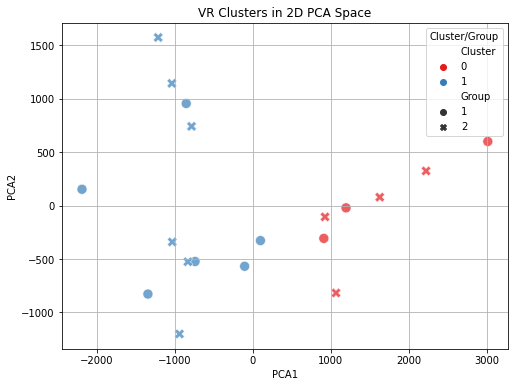

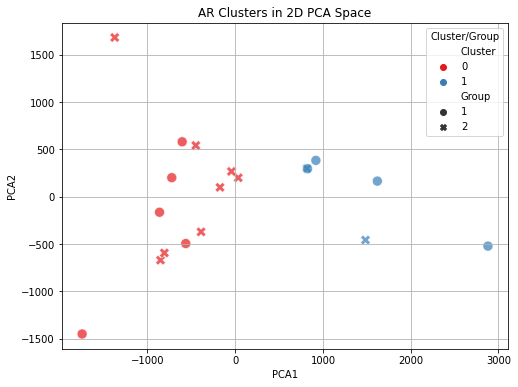


Participant, Group, VR Cluster, AR Cluster:
        Participant  Group  Cluster_VR  Cluster_AR
0    Participant 1      1           1           0
1    Participant 2      2           1           0
2    Participant 3      2           1           0
3    Participant 4      2           1           0
4    Participant 5      1           1           0
5    Participant 6      2           0           0
6    Participant 7      2           1           0
7    Participant 8      1           1           0
8    Participant 9      1           1           1
9   Participant 10      1           1           0
10  Participant 11      2           1           0
11  Participant 12      1           0           1
12  Participant 13      1           1           0
13  Participant 14      2           0           0
14  Participant 15      1           0           1
15  Participant 16      2           0           1
16  Participant 17      1           0           1
17  Participant 18      2           0           0
18  

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Function to perform PCA and visualize clusters
def plot_pca_clusters(familiarity_matrix_df, cluster_data, title):
    # Perform PCA to reduce the familiarity matrix to 2D
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(familiarity_matrix_df)
    
    # Create a DataFrame for the PCA results and cluster data
    pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
    pca_df['Cluster'] = cluster_data['Cluster']
    pca_df['Group'] = cluster_data['Group']
    
    # Create a scatter plot for the clusters in 2D PCA space
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', style='Group', data=pca_df, palette='Set1', s=100, alpha=0.7)
    plt.title(title)
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.legend(title='Cluster/Group')
    plt.grid(True)
    plt.show()

# Plot VR clusters using PCA
plot_pca_clusters(vr_familiarity_matrix, vr_cluster_data, "VR Clusters in 2D PCA Space")

# Plot AR clusters using PCA
plot_pca_clusters(ar_familiarity_matrix, ar_cluster_data, "AR Clusters in 2D PCA Space")

# Display list of participants, group, and their VR/AR cluster assignments
participant_cluster_list = merged_clusters[['Participant', 'Group', 'Cluster_VR', 'Cluster_AR']]
print("\nParticipant, Group, VR Cluster, AR Cluster:\n", participant_cluster_list)

# Function to calculate mean and standard deviation for each cluster
def calculate_cluster_stats(cluster_data, time_column, cluster_column):
    cluster_data[time_column] = sheet1_data[time_column].dt.total_seconds()
    cluster_stats = cluster_data.groupby(cluster_column).agg({
        time_column: ['mean', 'std']
    }).reset_index()
    
    # Convert mean and std dev back to mm:ss format for readability
    cluster_stats[(time_column, 'mean')] = pd.to_timedelta(cluster_stats[(time_column, 'mean')], unit='s')
    cluster_stats[(time_column, 'std')] = pd.to_timedelta(cluster_stats[(time_column, 'std')], unit='s')
    
    return cluster_stats

# Calculate mean and standard deviation for VR clusters
vr_stats = calculate_cluster_stats(vr_cluster_data, 'VR TOTAL TIME', 'Cluster')

# Calculate mean and standard deviation for AR clusters
ar_stats = calculate_cluster_stats(ar_cluster_data, 'AT TOTAL TIME', 'Cluster')
# Display the cluster statistics
print("\nVR Cluster Stats (mean and std dev):\n", vr_stats)
print("\nAR Cluster Stats (mean and std dev):\n", ar_stats)


Participants in Cluster 0 for both VR and AR: 3
Participants in Cluster 1 for both VR and AR: 2
Participants who switched clusters: 14

Participants who switched clusters:
       Participant  Cluster_VR  Cluster_AR
0    Participant 1           1           0
1    Participant 2           1           0
2    Participant 3           1           0
3    Participant 4           1           0
4    Participant 5           1           0
6    Participant 7           1           0
7    Participant 8           1           0
9   Participant 10           1           0
10  Participant 11           1           0
11  Participant 12           0           1
12  Participant 13           1           0
14  Participant 15           0           1
15  Participant 16           0           1
16  Participant 17           0           1


Participants in Cluster 0 for both VR and AR: 3
Participants in Cluster 1 for both VR and AR: 2
Participants who switched clusters: 14

Participants who switched clusters:
       Participant  Cluster_VR  Group  Cluster_AR
0    Participant 1           1      1           0
1    Participant 2           1      2           0
2    Participant 3           1      2           0
3    Participant 4           1      2           0
4    Participant 5           1      1           0
6    Participant 7           1      2           0
7    Participant 8           1      1           0
9   Participant 10           1      1           0
10  Participant 11           1      2           0
11  Participant 12           0      1           1
12  Participant 13           1      1           0
14  Participant 15           0      1           1
15  Participant 16           0      2           1
16  Participant 17           0      1           1


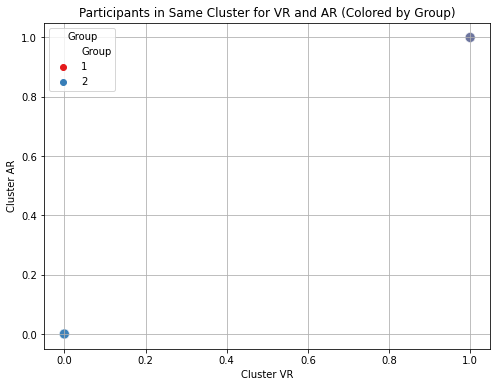

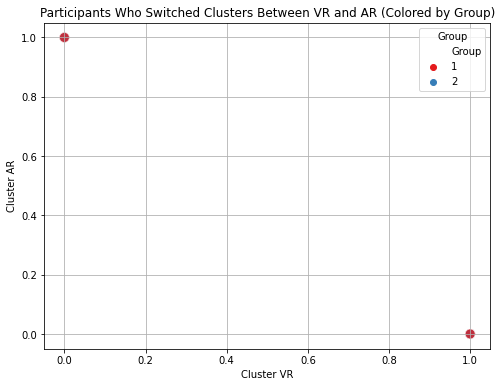


Cluster Statistics:
   Cluster  Average Time (seconds)  Std Dev (seconds)  \
0        0             1058.714286         251.254661   
1        1             1740.833333         234.720272   

                          Group Members  
0                 [2, 1, 2, 1, 2, 1, 2]  
1  [1, 2, 2, 2, 1, 2, 1, 1, 1, 2, 1, 2]  



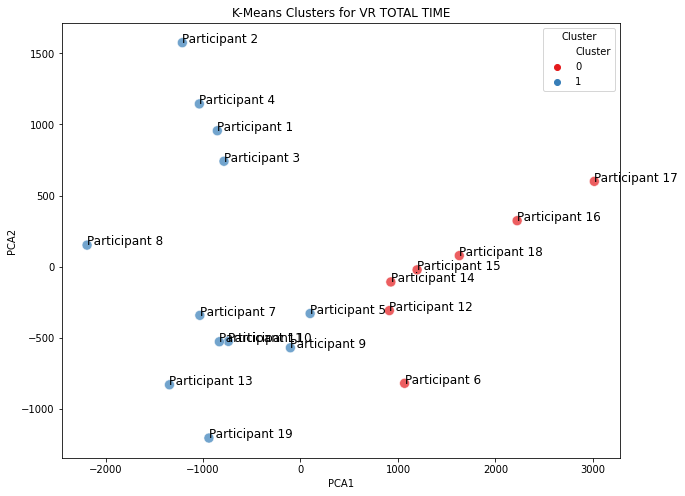

KeyError: "Column(s) ['AR TOTAL TIME'] do not exist"

In [1]:
sr_no = [4, 3, 1, 2, 5, 7, 8, 6, 12, 10, 9, 11, 13, 14, 16, 18, 19, 20, 21]
group = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

In [21]:
import pandas as pd
from datetime import time


file_path = 'VR_Timing.xlsx'

# Read the Excel file
df = pd.read_excel(file_path)

def time_to_seconds(time_obj):
    return time_obj.hour * 3600 + time_obj.minute * 60 + time_obj.second + time_obj.microsecond / 1e6
# Display the first few rows of the data
print(df.head())

   currentStep      P1 duration      P2 duration      P3 duration  \
0            0  00:00:09.823000  00:00:09.823000  00:00:05.446000   
1            1  00:00:34.454000  00:00:34.454000  00:00:48.220000   
2            2  00:00:20.396000  00:00:20.396000  00:00:23.409000   
3            3  00:00:42.676000  00:00:42.676000  00:00:47.022000   
4            4  00:03:21.887000  00:03:21.887000  00:01:17.611000   

       P4 duration      P5 duration      P6 duration      P8 duration  \
0  00:00:05.800000  00:00:05.423000  00:00:41.492000  00:00:09.259000   
1  00:00:37.700000  00:00:15.652000  00:00:14.931000  00:00:22.421000   
2  00:00:15.100000  00:00:14.309000  00:00:53.331000  00:00:16.254000   
3  00:03:23.700000  00:00:39.044000  00:00:27.966000  00:02:52.191000   
4  00:00:50.700000  00:02:06.313000  00:02:18.603000  00:02:17.819000   

       P9 duration     P10 duration     P11 duration     P12 duration  \
0  00:00:09.003000  00:00:21.477000  00:00:09.581000  00:00:22.340000   


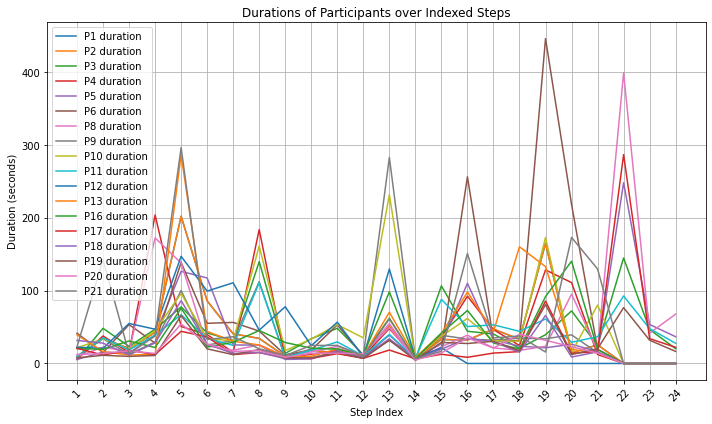

In [22]:
for column in df.columns[1:]:
    df[column] = df[column].apply(lambda x: time_to_seconds(x) if pd.notnull(x) else 0)

# Create an index-based step list for x-axis (starting from 1)
x_values = range(1, len(df) + 1)

# Plot the durations of all participants over the index-based steps
plt.figure(figsize=(10, 6))
for column in df.columns[1:]:
    plt.plot(x_values, df[column], label=column)

# Customize the plot
plt.title('Durations of Participants over Indexed Steps')
plt.xlabel('Step Index')
plt.ylabel('Duration (seconds)')

# Set x-axis ticks and labels to display each index as a step
plt.xticks(ticks=x_values, labels=x_values, rotation=45)

plt.legend(loc='best')
plt.grid(True)

# Display the plot
plt.tight_layout()
plt.show()

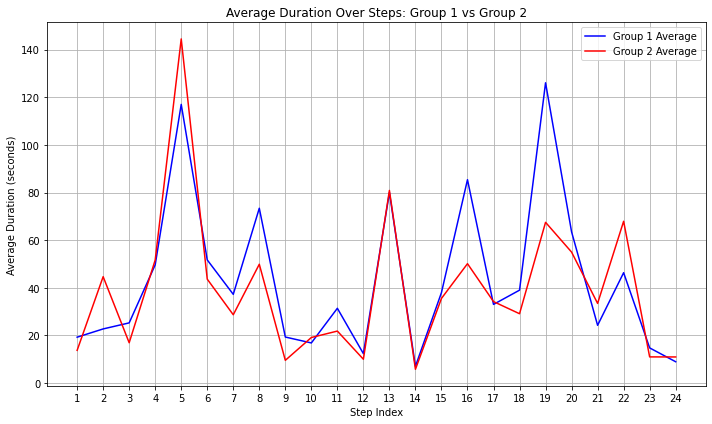

Average time at each step for Group 1:
0      19.291778
1      22.755333
2      25.293222
3      49.650778
4     116.986222
5      51.719444
6      37.270111
7      73.402222
8      19.359333
9      16.871889
10     31.415778
11     12.385333
12     80.006667
13      7.073778
14     38.004889
15     85.387111
16     33.043111
17     39.026556
18    126.052889
19     63.496889
20     24.270333
21     46.351000
22     14.793222
23      8.985333
dtype: float64

Average time at each step for Group 2:
0      13.764000
1      44.686000
2      16.956750
3      51.689750
4     144.459250
5      43.647625
6      28.701125
7      49.903375
8       9.576625
9      19.156750
10     21.854500
11     10.040000
12     80.878000
13      5.821000
14     35.557625
15     50.134625
16     34.225625
17     29.136625
18     67.494875
19     54.995875
20     33.460625
21     67.929625
22     11.018875
23     10.991500
dtype: float64


In [24]:
participant_columns = {int(col.split()[0][1:]): col for col in df.columns if 'P' in col}

# Separate participants into groups based on sr_no and group mapping
group1_columns = [participant_columns[sr] for sr, grp in zip(sr_no, group) if grp == 1 and sr in participant_columns]
group2_columns = [participant_columns[sr] for sr, grp in zip(sr_no, group) if grp == 2 and sr in participant_columns]

# Calculate the average duration at each step for both groups
group1_avg = df[group1_columns].mean(axis=1)
group2_avg = df[group2_columns].mean(axis=1)

# Plotting the average times for both groups
plt.figure(figsize=(10, 6))

# Plot Group 1
plt.plot(range(1, len(df) + 1), group1_avg, label='Group 1 Average', color='blue')

# Plot Group 2
plt.plot(range(1, len(df) + 1), group2_avg, label='Group 2 Average', color='red')

# Customize the plot
plt.title('Average Duration Over Steps: Group 1 vs Group 2')
plt.xlabel('Step Index')
plt.ylabel('Average Duration (seconds)')
plt.xticks(ticks=range(1, len(df) + 1))
plt.legend(loc='best')
plt.grid(True)

# Display the plot
plt.tight_layout()
plt.show()

# Print average times for each group at each step for further analysis
print("Average time at each step for Group 1:")
print(group1_avg)

print("\nAverage time at each step for Group 2:")
print(group2_avg)


In [28]:
from scipy.stats import mannwhitneyu
import pandas as pd

# Group 1 average times
group1_avg = pd.Series([
    19.291778, 22.755333, 25.293222, 49.650778, 116.986222, 51.719444, 37.270111, 73.402222, 19.359333, 16.871889,
    31.415778, 12.385333, 80.006667, 7.073778, 38.004889, 85.387111, 33.043111, 39.026556, 126.052889, 63.496889,
    24.270333, 46.351, 14.793222, 8.985333
])

# Group 2 average times
group2_avg = pd.Series([
    13.764, 44.686, 16.95675, 51.68975, 144.45925, 43.647625, 28.701125, 49.903375, 9.576625, 19.15675,
    21.8545, 10.04, 80.878, 5.821, 35.557625, 50.134625, 34.225625, 29.136625, 67.494875, 54.995875,
    33.460625, 67.929625, 11.018875, 10.9915
])

# Perform the Mann-Whitney U test for each step
p_values = []
for g1, g2 in zip(group1_avg, group2_avg):
    stat, p = mannwhitneyu([g1], [g2], alternative='two-sided')
    p_values.append(p)

# Create a DataFrame to display the results
results = pd.DataFrame({
    'Step': range(1, len(group1_avg) + 1),
    'Group 1 Avg': group1_avg,
    'Group 2 Avg': group2_avg,
    'p-value': p_values
})

# Display the results
print(results)


    Step  Group 1 Avg  Group 2 Avg  p-value
0      1    19.291778    13.764000      1.0
1      2    22.755333    44.686000      1.0
2      3    25.293222    16.956750      1.0
3      4    49.650778    51.689750      1.0
4      5   116.986222   144.459250      1.0
5      6    51.719444    43.647625      1.0
6      7    37.270111    28.701125      1.0
7      8    73.402222    49.903375      1.0
8      9    19.359333     9.576625      1.0
9     10    16.871889    19.156750      1.0
10    11    31.415778    21.854500      1.0
11    12    12.385333    10.040000      1.0
12    13    80.006667    80.878000      1.0
13    14     7.073778     5.821000      1.0
14    15    38.004889    35.557625      1.0
15    16    85.387111    50.134625      1.0
16    17    33.043111    34.225625      1.0
17    18    39.026556    29.136625      1.0
18    19   126.052889    67.494875      1.0
19    20    63.496889    54.995875      1.0
20    21    24.270333    33.460625      1.0
21    22    46.351000    67.9296

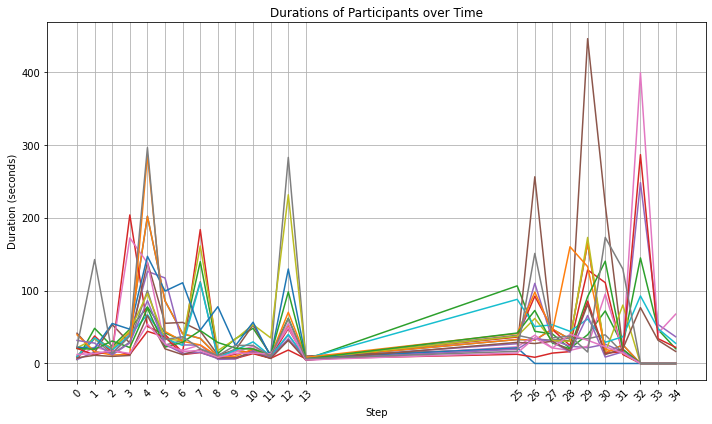

In [20]:
missing_data = df[df['currentStep'].between(13, 25)]
print(missing_data)

    currentStep  P1 duration  P2 duration  P3 duration  P4 duration  \
13           13        6.661        6.661        5.699          7.3   
14           25       32.879       32.879      106.452         36.2   

    P5 duration  P6 duration  P8 duration  P9 duration  P10 duration  \
13        6.474       10.222        4.273        6.242         6.529   
14       27.086       20.297       22.878       38.716        37.311   

    P11 duration  P12 duration  P13 duration  P16 duration  P17 duration  \
13         6.789         7.022         8.366         6.363         6.385   
14        87.952        21.463        41.075        41.743        12.601   

    P18 duration  P19 duration  P20 duration  P21 duration  
13         5.479         4.599         4.943         6.610  
14        19.507        28.917        14.451        16.699  


In [31]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# Grouping of participants
group1_sr_no = [1, 5, 6, 12, 10, 11, 13, 16, 19]  # Group 1 participants based on sr_no
group2_sr_no = [2, 3, 4, 7, 8, 9, 14, 17, 18, 20, 21]  # Group 2 participants based on sr_no

file_path = 'VR_Timing.xlsx'
df = pd.read_excel(file_path)

# Extracting participant columns from headers (only if they exist in the dataframe)
group1_columns = [f'P{sr_no} duration' for sr_no in group1_sr_no if f'P{sr_no} duration' in df.columns]
group2_columns = [f'P{sr_no} duration' for sr_no in group2_sr_no if f'P{sr_no} duration' in df.columns]

# Function to convert datetime.time objects to total seconds
def time_to_seconds(time_obj):
    if pd.isna(time_obj):  # Handle missing values
        return np.nan
    return time_obj.hour * 3600 + time_obj.minute * 60 + time_obj.second + time_obj.microsecond / 1e6

# Convert all relevant columns to seconds
for col in group1_columns + group2_columns:
    df[col] = df[col].apply(time_to_seconds)

# Calculate average time for Group 1 and Group 2 at each step
group1_avg = df[group1_columns].mean(axis=1)
group2_avg = df[group2_columns].mean(axis=1)

# Perform Mann-Whitney U test at each step to compare Group 1 and Group 2 average times
p_values = []
for step in range(len(df)):
    g1_values = df.loc[step, group1_columns].dropna()  # Remove NaN values
    g2_values = df.loc[step, group2_columns].dropna()  # Remove NaN values
    if len(g1_values) > 0 and len(g2_values) > 0:  # Ensure there are values to compare
        stat, p = mannwhitneyu(g1_values, g2_values, alternative='two-sided')
        p_values.append(p)
    else:
        p_values.append(np.nan)  # Append NaN if no comparison can be made

# Create a DataFrame to display the average times and p-values
results = pd.DataFrame({
    'Step': df['currentStep'],
    'Group 1 Avg (seconds)': group1_avg,
    'Group 2 Avg (seconds)': group2_avg,
    'p-value': p_values
})

# Display the results
print(results)


    Step  Group 1 Avg (seconds)  Group 2 Avg (seconds)   p-value
0      0              19.738778              14.096889  0.507582
1      1              22.394667              41.372556  0.200179
2      2              25.881667              16.492111  0.353588
3      3              31.759222              65.191333  0.507582
4      4             133.784778             116.509778  0.452679
5      5              56.853778              37.708889  0.309630
6      6              40.089778              24.053000  0.353588
7      7              56.818000              62.598889  0.452679
8      8              19.650333               9.068667  0.269443
9      9              17.495000              17.180222  0.894572
10    10              31.034111              21.304778  0.250018
11    11              12.184556               9.913778  0.894572
12    12              80.432222              73.514111  0.894572
13    13               7.002778               5.954667  0.102168
14    25              37.

In [ ]:
«